____
**Universidad Tecnológica Nacional, Buenos Aires**

**Ingeniería Industrial**

**Cátedra de Ciencia de Datos - Curso I5521 - Turno sabado mañana**

**Elaborado por: Agustin Velazquez**

**Editado por: Santiago Chas**
____

Cuantificar la variación morfológica del Iris con las flores de tres especies relacionadas.

El conjunto de datos contiene `50` muestras de cada una de tres especies de Iris (`Iris setosa`, `Iris virginica` e `Iris versicolor`). Se midió cuatro rasgos de cada muestra: lo largo y lo ancho del sépalos y pétalos, en centímetros. Basado en la combinación de estos cuatro rasgos.

https://es.wikipedia.org/wiki/Iris_flor_conjunto_de_datos

Los datos son:

| Columna | Descripcion |
| --- | --- |
| ID | Unique ID |
| SepalLengthCm | Length of the sepal (cm) |
| SepalWidthCm | Width of the sepal (cm) |
| PetalLengthCm | Length of the petal (cm) |
| PetalWidthCm | Width of the petal (cm) |
| Species | name |

**Objetivo: Clasificar las tres especies de flores segun los datos**

In [47]:
# Importamos algunas de las librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#from IPython.display import Image

In [48]:
import warnings
warnings.filterwarnings('ignore')

In [49]:
# Cargamos el dataset
col_names = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm','Species']
iris_df = pd.read_csv("Iris.csv")
iris_df = iris_df[col_names]
# Observamos una parte de los datos
iris_df.tail(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [50]:
# Nuestro objetivo es Species, entonces vemos cuanto tenemos
print("Species")
print(iris_df['Species'].unique())

Species
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


## Pairplot: 

**Con un pairplot podemos visualizar facilmente similitudes y diferencias entre especies utilizando dos caracteristicas**

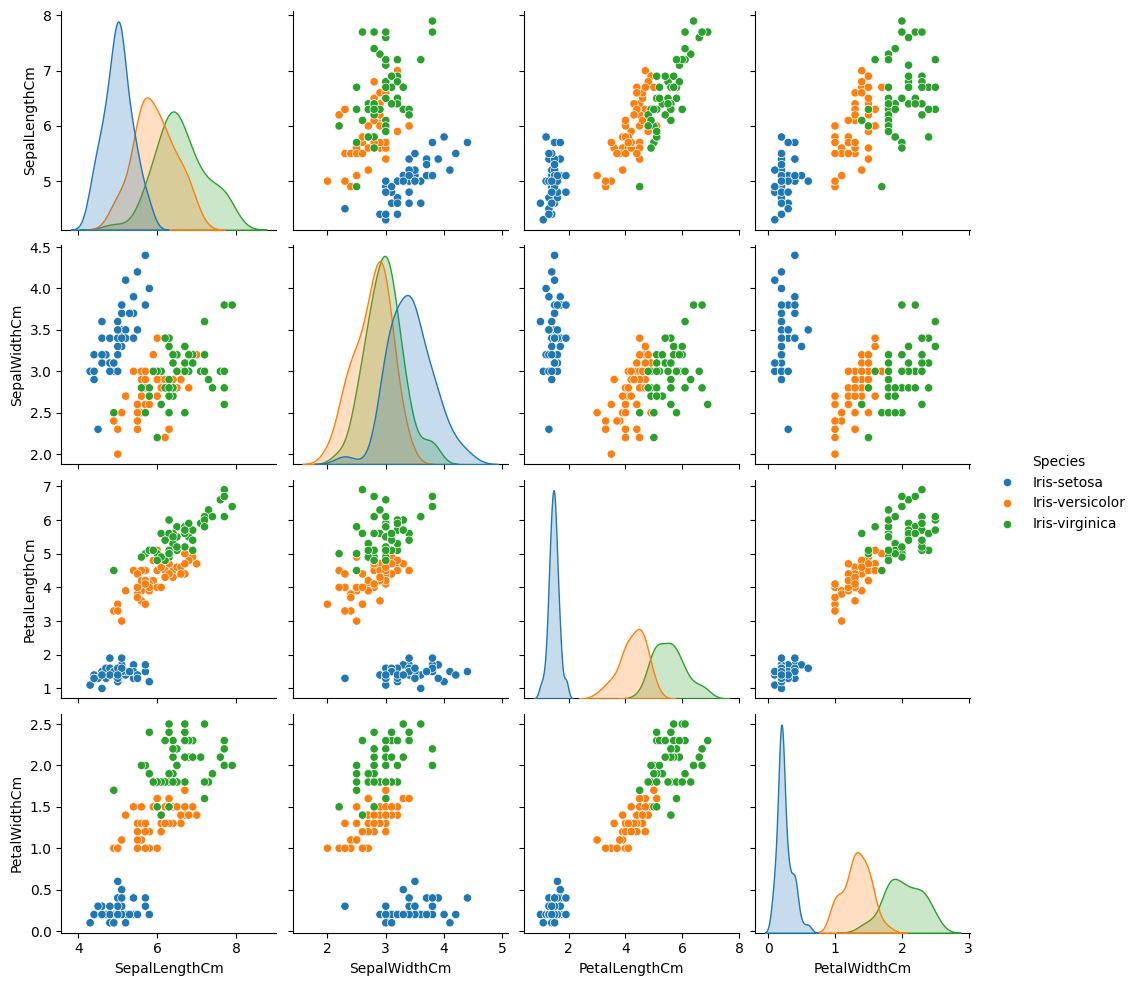

In [51]:
sns.pairplot(data=iris_df, hue='Species')
plt.show()

## Analizando Pairplot

    1. Cual es el significado de los colores?

    2. Que datos podemos extraer de la primer columna del pairplot?
    
    3. Que otras conclusiones se pueden extraer del resto del pairplot?

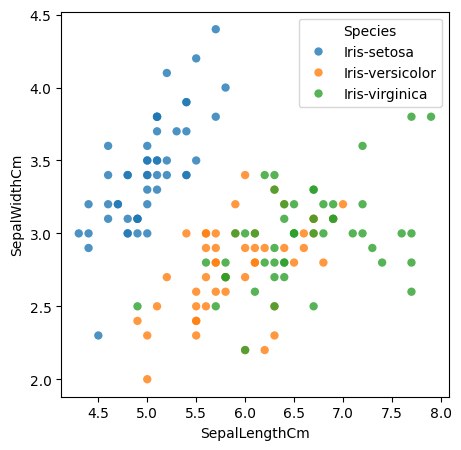

In [52]:
# Un scatter plot para visualizar dos variables
fig, (ax0) = plt.subplots(1,1,figsize=(5,5))
g=sns.scatterplot(x="SepalLengthCm", y="SepalWidthCm", data=iris_df, hue = 'Species', 
                  linewidth=0, alpha = 0.8,ax=ax0)

# Veamos como guardar una imagen,
plot_name = "test_img"
plot_save = str(plot_name)
plt.savefig(plot_save+".pdf",dpi=300)
plt.savefig(plot_save+".png",dpi=300)
plt.show()

## Multi-Class Problem:

**Hay tres tipos de Especies $\rightarrow$ Multi class problem!**

La estrategia que vamos a utilizar es: One vs Rest (OvR)

## Features & Target


La idea es desarrollar un `clasificador binario` para cada clase, distinguiéndola del resto (`rest`), y luego quedarnos con el clasificador que da la mayor probabilidad.

Si un problema es multi-class (`n` clases) el `One vs Rest` va a construir `n` modelos binarios, uno por cada clase compitiendo contra todas las demás.

Si tenemos tres clases, `A`, `B` and `C`. El `OvR` va a estar compuesto de 3 clasificadores binarios: `A` vs `resto`, `B` vs `resto`, y `C` vs `resto`.

Finalmente la muestra $x_i$ es asignada a la clase cuyo clasificador binario devuelve la mayor probabilidad.


In [53]:
# Nombre de columnas
column_names = iris_df.columns.values
# Columna target
targets_name = ['Species']
# Nombres de columnas que no estan en el target
features_names = [i_c for i_c in column_names if i_c not in targets_name]
print('Features:',features_names)
print('Target:',targets_name)

Features: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Target: ['Species']


In [54]:
# 1) Separamos lo que son las features del target.
features = iris_df[features_names]           
target = iris_df[targets_name]
print(features)
print(target)

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0              5.1           3.5            1.4           0.2
1              4.9           3.0            1.4           0.2
2              4.7           3.2            1.3           0.2
3              4.6           3.1            1.5           0.2
4              5.0           3.6            1.4           0.2
..             ...           ...            ...           ...
145            6.7           3.0            5.2           2.3
146            6.3           2.5            5.0           1.9
147            6.5           3.0            5.2           2.0
148            6.2           3.4            5.4           2.3
149            5.9           3.0            5.1           1.8

[150 rows x 4 columns]
            Species
0       Iris-setosa
1       Iris-setosa
2       Iris-setosa
3       Iris-setosa
4       Iris-setosa
..              ...
145  Iris-virginica
146  Iris-virginica
147  Iris-virginica
148  Iris-virginica
149  Iris-vi

In [55]:
# Guardamos feature matrix en "X"
X = features.values
# Guardamos target vector in "Y"
Y = target.values                          

In [56]:
print(Y.shape)
print(X.shape)

(150, 1)
(150, 4)


## Label Encoder
**`LabelEncoder` recibe valores (array o columnas de `Pandas DataFrame`) y le asigna a cada valor unico una clase.** 

**Luego nos devuelve los valores "codificados" entre `0` y `n_clases - 1`.**


In [57]:
# Transformamos el label del target en formato numerico para poder procesarlo

# Importamos preprocessing de la libreria scikit-learn (a.k.a. sklearn)
from sklearn import preprocessing

# 1 - Primero creo un objeto (con determinados argumentos) que llama a la funcion que deseo
le = preprocessing.LabelEncoder()

# 2 - AL objeto le aplico la funcion fit a los datos desados 
Y = le.fit_transform(Y.ravel()) #.ravel() para evitar el warning!

# 3 - Agregamos la nueva columna a nuestro DataFrame
iris_df['EncodedSpecies'] = Y

print('Classes:',le.classes_)
print('Response variable after encoding:',Y)
iris_df.tail(10)

Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Response variable after encoding: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,EncodedSpecies
140,6.7,3.1,5.6,2.4,Iris-virginica,2
141,6.9,3.1,5.1,2.3,Iris-virginica,2
142,5.8,2.7,5.1,1.9,Iris-virginica,2
143,6.8,3.2,5.9,2.3,Iris-virginica,2
144,6.7,3.3,5.7,2.5,Iris-virginica,2
145,6.7,3.0,5.2,2.3,Iris-virginica,2
146,6.3,2.5,5.0,1.9,Iris-virginica,2
147,6.5,3.0,5.2,2.0,Iris-virginica,2
148,6.2,3.4,5.4,2.3,Iris-virginica,2
149,5.9,3.0,5.1,1.8,Iris-virginica,2


## Split train & test

In [58]:
# Separar train y test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.4, random_state=4)
#random_state: seed utilizada para poder replicar el experimento ya que la funcion tiene
#componentes aleatorios
#test_size: numero entre 0 y 1 e indicar la proporcion del dataset que va a ser test. 
print(x_train.shape)
print(y_train.shape)

(90, 4)
(90,)


## Scaling

In [59]:
# Auto scaling train-set (mean = 0, std = 1)
scaler = preprocessing.StandardScaler().fit(x_train)
# Los valores de media y var quedan guardados en el scaler.
print(scaler.mean_)
print(scaler.var_)

[5.89       3.05       3.90666667 1.27888889]
[0.65112222 0.15983333 2.78973333 0.55344321]


In [60]:
# Transformamos los datos de x_train ...
x_train_scaled = scaler.transform(x_train)  
print(x_train_scaled.mean(axis=0))
print(x_train_scaled.std(axis=0))

[-1.82570008e-15 -1.78375833e-15  2.02307307e-16  2.07241631e-16]
[1. 1. 1. 1.]


**Ahora vamos a estandarizar los datos de test que una vez aplicado no deben tocarse hasta la validacion**

In [61]:
x_test_scaled = scaler.transform(x_test)
print(x_test_scaled.mean(axis=0))
print(x_test_scaled.std(axis=0))

[-0.14458243  0.02501303 -0.22152379 -0.26958652]
[1.05006824 1.19190877 1.11436585 1.03427381]


**Repasemos...**

- **Cual es el objetivo de escalar los datos?**


- **Por que no escalamos y_test?**


- **Por que $\mu_i \neq 0 $ y $\sigma_i \neq 1$ en `x_test_scaled`?**

## GridSearchCV

**Vamos a ver como se utilizan la `LR` con la libreria `sklearn`.**

**Previamente, crearemos un objeto `GridSearchCV` (Grid Search Cross-Validation) al cual le pasaremos un diccionario (`dict`) de Python cuyas `keys` serán los hyperparametros, y sus `values`, seran los distintos valores que querramos evaluar.**

# Regresión Logística

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Creamos el modelo de Regresion Logistica

# solver='lbfgs' es para problemas multiclase
log_reg = LogisticRegression(solver='lbfgs', 
                              max_iter=1000)

# Hiperparametros a evaluar
parameters = {'C':[0.01, 0.1, 1, 10, 100],
              'l1_ratio':[0, 1, 0.5]}

# GridSearchCV con validacion cruzada de 5 folds
clf_log = GridSearchCV(log_reg, # modelo
                       param_grid = parameters, # Hiperparametros
                       refit = True, # refit nos devuelve el modelo con los mejores parametros encontrados 
                       cv = 5, # cv indica la cantidad de folds
                       verbose=1)

# Entrenamos el modelo
clf_log.fit(x_train_scaled, y_train.ravel())
print("\nModelo de Regresión Logística entrenado correctamente")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Modelo de Regresión Logística entrenado correctamente


In [63]:
# Toda la informacion del entrenamiento esta en cv_results_
scores = clf_log.cv_results_
#Veamosla ...
scores_df = pd.DataFrame.from_dict(scores)
scores_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.010112,0.001326,0.001794,0.000204,0.01,0.0,"{'C': 0.01, 'l1_ratio': 0}",0.777778,0.777778,0.944444,0.777778,0.944444,0.844444,0.08165,13
1,0.010160,0.002082,0.001811,0.000224,0.01,1.0,"{'C': 0.01, 'l1_ratio': 1}",0.777778,0.777778,0.944444,0.777778,0.944444,0.844444,0.08165,13
2,0.008154,0.000824,0.001497,0.000257,0.01,0.5,"{'C': 0.01, 'l1_ratio': 0.5}",0.777778,0.777778,0.944444,0.777778,0.944444,0.844444,0.08165,13
3,0.006660,0.000913,0.001307,0.000462,0.10,0.0,"{'C': 0.1, 'l1_ratio': 0}",0.833333,0.833333,1.000000,0.833333,1.000000,0.900000,0.08165,10
4,0.005947,0.001193,0.001158,0.000251,0.10,1.0,"{'C': 0.1, 'l1_ratio': 1}",0.833333,0.833333,1.000000,0.833333,1.000000,0.900000,0.08165,10


In [64]:
csv_name = "CV_results.csv"
csv_save = str("CV_results.csv")
scores_df.to_csv(csv_save)

In [65]:
# Mejores parametros encontrados para Regresion Logistica
print("Mejores parametros (Regresión Logística): %s con un score de %0.2f" % (clf_log.best_params_, clf_log.best_score_))

Mejores parametros (Regresión Logística): {'C': 10, 'l1_ratio': 0} con un score de 0.97


**Que es lo que hizo internamente GridSearchCV?**
 
![Grid_SearchCV](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)
[**Fuente**](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

## Predict
**Utilizando `predict` utilizamos el/los modelos ya entrenada previamente para estimar $\hat{y}$ a partir de `x_test`**

In [66]:
# Prediction sobre las muestras de test
y_pred = clf_log.predict(x_test_scaled)
print(y_pred)

[2 0 2 2 2 1 2 0 0 1 0 0 0 1 2 0 1 0 0 2 0 2 1 0 0 0 0 0 0 2 1 0 2 0 1 2 2
 1 1 0 2 0 1 0 2 0 0 1 1 2 0 1 2 2 1 1 0 1 2 1]


**Con score**

In [67]:
# Model prediciton
print(clf_log.score(x_test_scaled,y_test.ravel())) #obtenemos el promedio de la accuracy

0.9666666666666667


## Confusion matrix

**Es un herramienta que permite la visualización del desempeño de un algoritmo que se emplea en aprendizaje supervisado.** 

**Cada columna de la matriz representa el número de predicciones de cada clase, mientras que cada fila representa a las instancias en la clase real.**

**Uno de los beneficios de las matrices de confusión es que facilitan ver si el sistema está classificando erroneamente las clases.**

In [68]:
# Plot Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[25  0  0]
 [ 0 16  1]
 [ 0  1 17]]


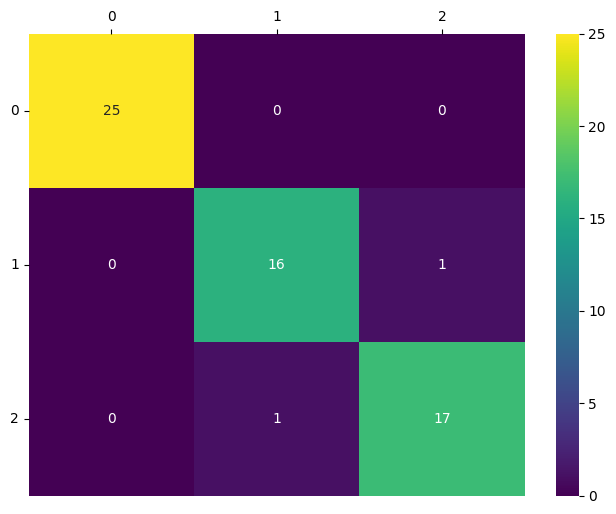

In [69]:
import matplotlib.pyplot as plt
import numpy as np

df_cm = pd.DataFrame(cm, #Valores
                     index = [i for i in np.unique(Y)], # rows
                     columns = [i for i in np.unique(Y)]) # Column
plt.figure(figsize = (8,6))
ax = sns.heatmap(df_cm, annot=True, cmap="viridis")
plt.yticks(rotation=0)
ax.xaxis.tick_top() # x axis on top
ax.xaxis.set_label_position('top')
plt.show()

# Resumen

1.  Dividimos el dataset en `features` y `target` ( $X$ e $Y$ )
    
2.  Aplicamos un `encoder` a la variable objetivo
    
3.  Separamos nuestro dataset en train y test set $\rightarrow$ ${X}_{train}$, ${Y}_{train}$, ${X}_{test}$, ${Y}_{test}$
    
4.  Estandarizamos el set de entrenamiento ($\mu$ y $\sigma$), y luego ${X}_{test}$. 

5.  Aplicamos un cross validation grid search con kernel linea y gaussiano y diversos parametros sobre el train set

6.  Realizamos la `prediccion` sobre el test set y obtenemos el `score`

7.  Realizamos una `Matriz de Confusion` para obtener una mejor vision del error obtenido